
# Waste-to-Energy Facility Location–Allocation Planning (MILP)

This notebook formulates and solves a mixed-integer linear programming (MILP) model for locating **exactly three waste-to-energy (WtE) facilities** among **10 pre-selected candidate sites**.

Ten organic-waste sources must each send **all of their waste to exactly one selected facility**. At each selected site, the model chooses one technology:

- Modular pyrolysis (PYR)
- Incineration (INC)
- Anaerobic digestion (AD)

The model minimizes equivalent annual net cost over a 10-year project life, including:

- annualized capital cost using the **capital recovery factor (CRF)**,
- operating cost,
- waste transportation cost,
- minus revenue from energy production.

Because both waste-source coordinates and candidate-site coordinates are fixed, all Euclidean source-to-site distances are **pre-computed parameters**, so the optimization model remains an MILP.


## 1. Decision Variables

Let:

- $i \in \mathcal{I}$: waste sources
- $s \in \mathcal{S}$: candidate facility sites
- $k \in \mathcal{K}$: WtE technologies

### Facility technology selection

$$
z_{s,k} =
\begin{cases}
1, & \text{if technology } k \text{ is built at candidate site } s\\
0, & \text{otherwise}
\end{cases}
$$

### Source-to-facility allocation

$$
a_{i,s} =
\begin{cases}
1, & \text{if waste source } i \text{ is assigned to site } s\\
0, & \text{otherwise}
\end{cases}
$$

Each source must send **all of its waste to exactly one facility**.

### Waste processed by technology

$$ Q_{s,k} \ge 0 $$

where $Q_{s,k}$ is the annual waste processed at site $s$ using technology $k$, in t/year.



## 2. Fixed Parameters

### Waste-source parameters

- $(X_i,Y_i)$: coordinates of waste source $i$
- $W_i$: annual organic-waste generation of source $i$, t/year

### Candidate-site parameters

- $(X_s,Y_s)$: fixed coordinates of candidate site $s$

### Technology parameters

- $K_k$: upfront installation cost, \$
- $\bar Q_k$: annual processing capacity, t/year
- $c_k^{op}$: operating cost, \$/t
- $e_k$: net saleable energy yield, MWh/t

### Economic parameters

- $p^E$: energy selling price, \$/MWh
- $c^{tr}$: transportation cost, \$/t-km
- $r$: annual discount rate
- $N=10$: project life, years

### Pre-computed parameters

The Euclidean distance from source $i$ to candidate site $s$ is

$$ d_{i,s} = \sqrt{(X_i-X_s)^2+(Y_i-Y_s)^2}.$$

Because all coordinates are fixed, $d_{i,s}$ is calculated **before** optimization.

The capital recovery factor is

$$ CRF = \frac{r(1+r)^N}{(1+r)^N-1}. $$

The annualized capital cost of technology $k$ is therefore

$$ K_k^{ann}=CRF\,K_k. $$


## 3. Objective Function

The objective is to minimize the **equivalent annual net cost**:

$$
\min Z =
CRF\sum_{s,k}K_k z_{s,k}
+
\sum_{s,k}c_k^{op}Q_{s,k}
+
c^{tr}\sum_{i,s}W_i d_{i,s}a_{i,s}
-
p^E\sum_{s,k}e_kQ_{s,k}.
$$

The four terms represent:

1. annualized installation cost,
2. annual operating cost,
3. annual transportation cost,
4. annual energy revenue.

There is **no energy-demand constraint**. Energy production simply generates revenue that offsets system cost.



## 4. Constraints

### Exactly three facilities

$$
\sum_{s\in\mathcal S}\sum_{k\in\mathcal K}z_{s,k}=3.
$$

### At most one technology per candidate site

$$
\sum_{k\in\mathcal K}z_{s,k}\le 1
\qquad \forall s.
$$

### Every waste source is assigned to exactly one facility

$$
\sum_{s\in\mathcal S}a_{i,s}=1
\qquad \forall i.
$$

### Waste can only be assigned to an active facility

$$
a_{i,s}\le \sum_{k\in\mathcal K}z_{s,k}
\qquad \forall i,s.
$$

### Every selected facility must serve at least one source

$$
\sum_{i\in\mathcal I}a_{i,s}
\ge
\sum_{k\in\mathcal K}z_{s,k}
\qquad \forall s.
$$

### Waste balance at each candidate site

$$
\sum_{k\in\mathcal K}Q_{s,k}
=
\sum_{i\in\mathcal I}W_i a_{i,s}
\qquad \forall s.
$$

### Technology capacity

$$
0\le Q_{s,k}\le \bar Q_k z_{s,k}
\qquad \forall s,k.
$$

### Variable domains

$$
z_{s,k}\in\{0,1\},\qquad
a_{i,s}\in\{0,1\},\qquad
Q_{s,k}\ge0.
$$


## 5. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyomo.environ import (
    ConcreteModel, Set, Param, Var, Binary, NonNegativeReals,
    Objective, Constraint, minimize, SolverFactory, value
)
from matplotlib.lines import Line2D

## 6. Input Data

Waste sources


,source,x,y,waste_tpy
0,W1,8,55,8500
1,W2,18,68,12000
2,W3,28,40,9500
3,W4,35,54,15000
4,W5,48,73,11000
5,W6,55,60,13500
6,W7,70,70,10000
7,W8,78,58,14500
8,W9,87,32,9000
9,W10,93,72,12500



Candidate sites


,site,x,y
0,S1,50,38
1,S2,24,52
2,S3,38,65
3,S4,60,50
4,S5,62,28
5,S6,74,44
6,S7,86,55
7,S8,30,76
8,S9,60,78
9,S10,82,86



Technology options


,technology,name,capex_USD,capacity_tpy,opex_USD_per_t,energy_MWh_per_t
0,PYR,Modular pyrolysis,9000000,45000,48,0.80
1,INC,Incineration,15000000,70000,62,0.95
2,AD,Anaerobic digestion,7000000,40000,35,0.55


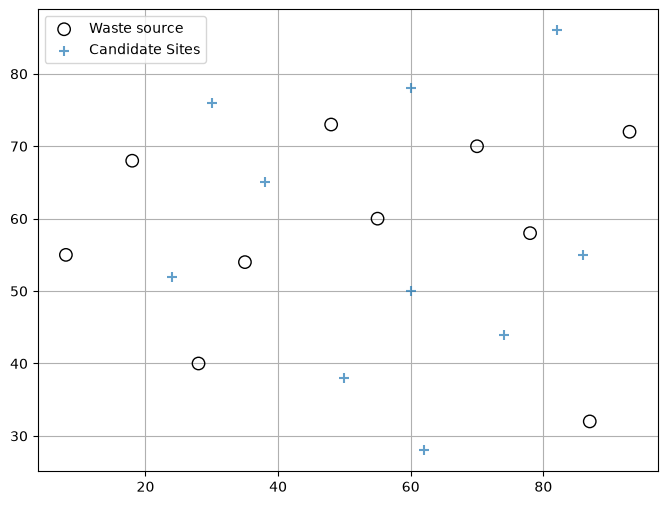

In [2]:
# -----------------------------
# Waste sources
# -----------------------------
sources = pd.DataFrame({
    "source": [f"W{i}" for i in range(1, 11)],
    "x": [ 8, 18, 28, 35, 48, 55, 70, 78, 87, 93],
    "y": [55, 68, 40, 54, 73, 60, 70, 58, 32, 72],
    "waste_tpy": [8500, 12000, 9500, 15000, 11000, 13500, 10000, 14500, 9000, 12500]
})

# -----------------------------
# Pre-selected candidate sites
# -----------------------------
sites = pd.DataFrame({
    "site": [f"S{i}" for i in range(1, 11)],
    "x": [50, 24, 38, 60, 62, 74, 86, 30, 60, 82],
    "y": [38, 52, 65, 50, 28, 44, 55, 76, 78, 86]
})

# -----------------------------
# WtE technology data
# -----------------------------
technologies = pd.DataFrame({
    "technology": ["PYR", "INC", "AD"],
    "name": ["Modular pyrolysis", "Incineration", "Anaerobic digestion"],
    "capex_USD": [9_000_000, 15_000_000, 7_000_000],
    "capacity_tpy": [45_000, 70_000, 40_000],
    "opex_USD_per_t": [48, 62, 35],
    "energy_MWh_per_t": [0.80, 0.95, 0.55]
})

# -----------------------------
# Economic assumptions
# -----------------------------
project_life = 10             # years
discount_rate = 0.08          # 8% per year
energy_price = 110.0          # USD/MWh
transport_cost = 0.18         # USD/(t-km)

print("Waste sources")
display(sources)

print("\nCandidate sites")
display(sites)

print("\nTechnology options")
display(technologies)


fig, ax = plt.subplots(figsize=(8, 6))

# Plot waste sources
ax.scatter(sources["x"], sources["y"], marker="o", s=80, facecolors="none",
    edgecolors="black", label="Waste source", zorder=3)
# Plot candidate WtE sites
ax.scatter(sites["x"], sites["y"], label="Candidate Sites",
    marker="+", s=55, alpha=0.7, zorder=2)
plt.legend()
plt.grid()
plt.show()

## 7. Pre-compute Distances, CRF, and Other Parameters

In [3]:
# Capital recovery factor
CRF = (discount_rate * (1 + discount_rate) ** project_life
    / ((1 + discount_rate) ** project_life - 1))

# Annualized capital cost for each technology
technologies["annualized_capex_USD_per_yr"] = technologies["capex_USD"] * CRF

# Net energy revenue per ton
technologies["energy_revenue_USD_per_t"] = (
    technologies["energy_MWh_per_t"] * energy_price
)

# Euclidean distance matrix
distance_matrix = pd.DataFrame(
    index=sources["source"],
    columns=sites["site"],
    dtype=float
)

for _, src in sources.iterrows():
    for _, st in sites.iterrows():
        distance_matrix.loc[src["source"], st["site"]] = np.sqrt(
            (src["x"] - st["x"]) ** 2
            + (src["y"] - st["y"]) ** 2
        )

print(f"Capital recovery factor (CRF): {CRF:.5f}")
print(f"Project life: {project_life} years")
print(f"Discount rate: {100*discount_rate:.1f}%")

print("\nTechnology economics after pre-computation")
display(
    technologies[
        [
            "technology", "name", "capacity_tpy",
            "annualized_capex_USD_per_yr",
            "opex_USD_per_t",
            "energy_MWh_per_t",
            "energy_revenue_USD_per_t"
        ]
    ]
)

print("\nSource-to-site Euclidean distances")
display(distance_matrix.round(2))

Capital recovery factor (CRF): 0.14903
Project life: 10 years
Discount rate: 8.0%

Technology economics after pre-computation


,technology,name,capacity_tpy,annualized_capex_USD_per_yr,opex_USD_per_t,energy_MWh_per_t,energy_revenue_USD_per_t
0,PYR,Modular pyrolysis,45000,1.341265e+06,48,0.80,88.0
1,INC,Incineration,70000,2.235442e+06,62,0.95,104.5
2,AD,Anaerobic digestion,40000,1.043206e+06,35,0.55,60.5



Source-to-site Euclidean distances


site,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10
source,,,,,,,,,,
W1,45.31,16.28,31.62,52.24,60.37,66.91,78.00,30.41,56.86,80.23
W2,43.86,17.09,20.22,45.69,59.46,60.93,69.23,14.42,43.17,66.48
W3,22.09,12.65,26.93,33.53,36.06,46.17,59.91,36.06,49.68,70.94
W4,21.93,11.18,11.40,25.32,37.48,40.26,51.01,22.56,34.66,56.86
W5,35.06,31.89,12.81,25.94,47.13,38.95,42.05,18.25,13.00,36.40
W6,22.56,32.02,17.72,11.18,32.76,24.84,31.40,29.68,18.68,37.48
W7,37.74,49.40,32.39,22.36,42.76,26.31,21.93,40.45,12.81,20.00
W8,34.41,54.33,40.61,19.70,34.00,14.56,8.54,51.26,26.91,28.28
W9,37.48,66.10,59.08,32.45,25.32,17.69,23.02,72.01,53.34,54.23



## 8. Build the Pyomo MILP

All nonlinear-looking geometric calculations have already been completed. The distance $d_{i,s}$ enters the Pyomo model only as a fixed parameter.


In [4]:
# -----------------------------
# Convert tabular data to dictionaries
# -----------------------------
I = sources["source"].tolist()
S = sites["site"].tolist()
K = technologies["technology"].tolist()

waste = sources.set_index("source")["waste_tpy"].to_dict()

capex = technologies.set_index("technology")["capex_USD"].to_dict()
capacity = technologies.set_index("technology")["capacity_tpy"].to_dict()
opex = technologies.set_index("technology")["opex_USD_per_t"].to_dict()
energy_yield = technologies.set_index("technology")["energy_MWh_per_t"].to_dict()

distance = {
    (i, s): float(distance_matrix.loc[i, s])
    for i in I
    for s in S
}

# -----------------------------
# Pyomo model
# -----------------------------
model = ConcreteModel()

model.I = Set(initialize=I)
model.S = Set(initialize=S)
model.K = Set(initialize=K)

model.W = Param(model.I, initialize=waste)
model.d = Param(model.I, model.S, initialize=distance)

# Decision variables
model.z = Var(model.S, model.K, domain=Binary)
model.a = Var(model.I, model.S, domain=Binary)
model.Q = Var(model.S, model.K, domain=NonNegativeReals)

# Objective components are kept explicit for readability
def objective_rule(m):
    annualized_capital = sum(
        CRF * capex[k] * m.z[s, k]
        for s in m.S for k in m.K
    )

    operating = sum(
        opex[k] * m.Q[s, k]
        for s in m.S for k in m.K
    )

    transportation = sum(
        transport_cost * m.W[i] * m.d[i, s] * m.a[i, s]
        for i in m.I for s in m.S
    )

    energy_revenue = sum(
        energy_price * energy_yield[k] * m.Q[s, k]
        for s in m.S for k in m.K
    )

    return annualized_capital + operating + transportation - energy_revenue

model.obj = Objective(rule=objective_rule, sense=minimize)

# Exactly three facilities
model.exactly_three = Constraint(
    expr=sum(model.z[s, k] for s in model.S for k in model.K) == 3
)

# At most one technology per site
def one_technology_rule(m, s):
    return sum(m.z[s, k] for k in m.K) <= 1

model.one_technology = Constraint(model.S, rule=one_technology_rule)

# Every source sends ALL waste to exactly one facility
def source_assignment_rule(m, i):
    return sum(m.a[i, s] for s in m.S) == 1

model.source_assignment = Constraint(model.I, rule=source_assignment_rule)

# Assignment only to a selected facility
def active_site_rule(m, i, s):
    return m.a[i, s] <= sum(m.z[s, k] for k in m.K)

model.active_site = Constraint(model.I, model.S, rule=active_site_rule)

# Every selected facility must serve at least one source
def used_facility_rule(m, s):
    return sum(m.a[i, s] for i in m.I) >= sum(m.z[s, k] for k in m.K)

model.used_facility = Constraint(model.S, rule=used_facility_rule)

# Waste balance at each site
def waste_balance_rule(m, s):
    return sum(m.Q[s, k] for k in m.K) == sum(
        m.W[i] * m.a[i, s] for i in m.I
    )

model.waste_balance = Constraint(model.S, rule=waste_balance_rule)

# Technology capacity
def capacity_rule(m, s, k):
    return m.Q[s, k] <= capacity[k] * m.z[s, k]

model.capacity = Constraint(model.S, model.K, rule=capacity_rule)

## 9. Solve with GLPK

In [5]:
solver = SolverFactory("glpk")
results = solver.solve(model, tee=True)

print("Solver status:", results.solver.status)
print("Termination condition:", results.solver.termination_condition)
print(f"Minimum equivalent annual net cost: ${value(model.obj):,.2f}/year")

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write C:\Users\Karl\AppData\Local\Temp\tmpqzkoebbu.glpk.raw --wglp C:\Users\Karl\AppData\Local\Temp\tmpdai_488w.glpk.glp
 --cpxlp C:\Users\Karl\AppData\Local\Temp\tmp8xp5airi.pyomo.lp
Reading problem data from 'C:\Users\Karl\AppData\Local\Temp\tmp8xp5airi.pyomo.lp'...
C:\Users\Karl\AppData\Local\Temp\tmp8xp5airi.pyomo.lp:1723: warning: lower bound of variable 'x2' redefined
C:\Users\Karl\AppData\Local\Temp\tmp8xp5airi.pyomo.lp:1723: warning: upper bound of variable 'x2' redefined
171 rows, 160 columns, 880 non-zeros
130 integer variables, all of which are binary
1853 lines were read
Writing problem data to 'C:\Users\Karl\AppData\Local\Temp\tmpdai_488w.glpk.glp'...
1565 lines were written
GLPK Integer Optimizer 5.0
171 rows, 160 columns, 880 non-zeros
130 integer variables, all of which are binary
Preprocessing...
100 hidden covering inequaliti(es) were detected
171 rows, 160 columns, 880 non-zeros
130 integer

## 10. Report Results

In [6]:
# -----------------------------
# Selected facilities
# -----------------------------
facility_rows = []

for s in S:
    for k in K:
        if value(model.z[s, k]) > 0.5:
            site_row = sites.loc[sites["site"] == s].iloc[0]
            tech_row = technologies.loc[technologies["technology"] == k].iloc[0]

            processed = value(model.Q[s, k])
            n_sources = sum(value(model.a[i, s]) > 0.5 for i in I)

            facility_rows.append({
                "site": s,
                "x": site_row["x"],
                "y": site_row["y"],
                "technology": k,
                "technology_name": tech_row["name"],
                "waste_processed_tpy": processed,
                "capacity_tpy": tech_row["capacity_tpy"],
                "capacity_utilization_%": 100 * processed / tech_row["capacity_tpy"],
                "sources_served": n_sources,
                "annualized_capex_USD": CRF * tech_row["capex_USD"],
                "annual_opex_USD": tech_row["opex_USD_per_t"] * processed,
                "annual_energy_MWh": tech_row["energy_MWh_per_t"] * processed,
                "annual_energy_revenue_USD": (
                    energy_price * tech_row["energy_MWh_per_t"] * processed
                )
            })

facility_results = pd.DataFrame(facility_rows)

# -----------------------------
# Source assignments
# -----------------------------
assignment_rows = []

for i in I:
    assigned_site = next(
        s for s in S if value(model.a[i, s]) > 0.5
    )
    chosen_tech = next(
        k for k in K if value(model.z[assigned_site, k]) > 0.5
    )

    src_row = sources.loc[sources["source"] == i].iloc[0]

    assignment_rows.append({
        "source": i,
        "waste_tpy": src_row["waste_tpy"],
        "source_x": src_row["x"],
        "source_y": src_row["y"],
        "assigned_site": assigned_site,
        "technology": chosen_tech,
        "distance": distance[(i, assigned_site)],
        "annual_transport_cost_USD": (
            transport_cost
            * src_row["waste_tpy"]
            * distance[(i, assigned_site)]
        )
    })

assignment_results = pd.DataFrame(assignment_rows)

# -----------------------------
# Cost summary
# -----------------------------
annualized_capital = sum(
    CRF * capex[k] * value(model.z[s, k])
    for s in S for k in K
)

operating_cost = sum(
    opex[k] * value(model.Q[s, k])
    for s in S for k in K
)

transportation_cost = sum(
    transport_cost
    * waste[i]
    * distance[(i, s)]
    * value(model.a[i, s])
    for i in I for s in S
)

energy_revenue = sum(
    energy_price
    * energy_yield[k]
    * value(model.Q[s, k])
    for s in S for k in K
)

summary_results = pd.DataFrame({
    "component": [
        "Annualized capital cost",
        "Annual operating cost",
        "Annual transportation cost",
        "Annual energy revenue",
        "Equivalent annual net cost"
    ],
    "USD_per_year": [
        annualized_capital,
        operating_cost,
        transportation_cost,
        -energy_revenue,
        value(model.obj)
    ]
})

print("Selected facilities")
display(facility_results.round(2))

print("\nWaste-source assignments")
display(assignment_results.round(2))

print("\nAnnual cost summary")
display(summary_results.round(2))

Selected facilities


,site,x,y,technology,technology_name,waste_processed_tpy,capacity_tpy,capacity_utilization_%,sources_served,annualized_capex_USD,annual_opex_USD,annual_energy_MWh,annual_energy_revenue_USD
0,S2,24,52,PYR,Modular pyrolysis,45000.0,45000,100.00,4,1341265.4,2160000.0,36000.0,3960000.0
1,S7,86,55,PYR,Modular pyrolysis,36000.0,45000,80.00,3,1341265.4,1728000.0,28800.0,3168000.0
2,S9,60,78,PYR,Modular pyrolysis,34500.0,45000,76.67,3,1341265.4,1656000.0,27600.0,3036000.0



Waste-source assignments


,source,waste_tpy,source_x,source_y,assigned_site,technology,distance,annual_transport_cost_USD
0,W1,8500,8,55,S2,PYR,16.28,24906.60
1,W2,12000,18,68,S2,PYR,17.09,36910.10
2,W3,9500,28,40,S2,PYR,12.65,21629.98
3,W4,15000,35,54,S2,PYR,11.18,30186.92
4,W5,11000,48,73,S9,PYR,13.00,25740.00
5,W6,13500,55,60,S9,PYR,18.68,45396.15
6,W7,10000,70,70,S9,PYR,12.81,23051.25
7,W8,14500,78,58,S7,PYR,8.54,22299.85
8,W9,9000,87,32,S7,PYR,23.02,37295.20
9,W10,12500,93,72,S7,PYR,18.38,41365.75



Annual cost summary


,component,USD_per_year
0,Annualized capital cost,4023796.19
1,Annual operating cost,5544000.00
2,Annual transportation cost,308781.78
3,Annual energy revenue,-10164000.00
4,Equivalent annual net cost,-287422.03


## 11. Plot Sources and Selected Facility Locations

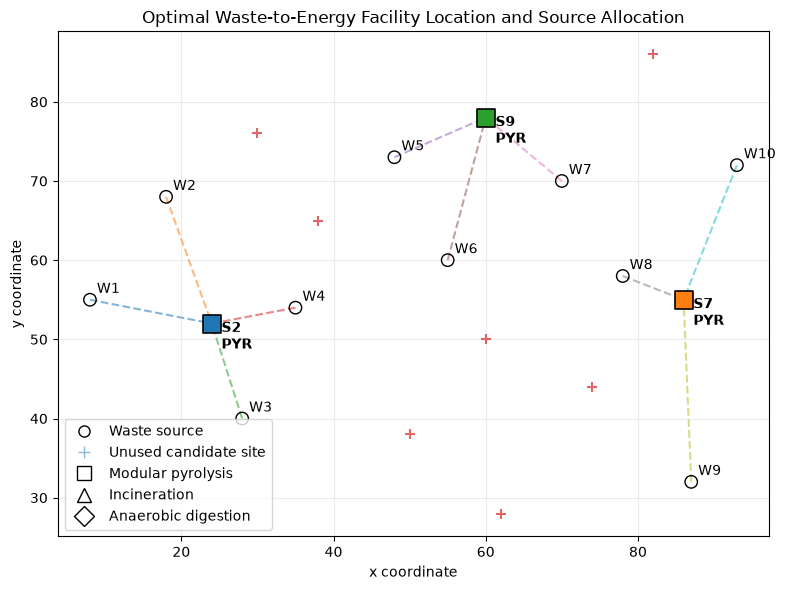

In [7]:
# Technology-specific markers
tech_markers = {
    "PYR": "s",   # square
    "INC": "^",   # triangle
    "AD": "D"     # diamond
}

tech_names = technologies.set_index("technology")["name"].to_dict()

fig, ax = plt.subplots(figsize=(8, 6))

# Plot waste sources
ax.scatter(sources["x"], sources["y"], marker="o", s=80, facecolors="none",
    edgecolors="black", label="Waste source", zorder=3)

# Label sources
for _, row in sources.iterrows():
    ax.annotate(
        row["source"],
        (row["x"], row["y"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

# Plot allocation lines
for _, row in assignment_results.iterrows():
    src = sources.loc[sources["source"] == row["source"]].iloc[0]
    st = sites.loc[sites["site"] == row["assigned_site"]].iloc[0]

    ax.plot([src["x"], st["x"]], [src["y"], st["y"]],
        linestyle="--", linewidth=1.5, alpha=0.55, zorder=1)

# Plot ONLY the marker corresponding to the technology
# actually chosen at each selected facility.
for _, row in facility_results.iterrows():
    ax.scatter(row["x"], row["y"],
        marker=tech_markers[row["technology"]],
        s=180, edgecolors="black",
        linewidths=1.2, zorder=4)

    ax.annotate(f'{row["site"]}\n{row["technology"]}',
        (row["x"], row["y"]), xytext=(7, -18),
        textcoords="offset points",
        fontweight="bold")

# Optional: show unused candidate sites
unused_sites = sites[~sites["site"].isin(facility_results["site"])]
ax.scatter(unused_sites["x"], unused_sites["y"],
    marker="+", s=55, alpha=0.7, zorder=2)

# Build a custom legend that ALWAYS lists all technologies,
# even if a technology is not selected in the optimal solution.
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor="none",
        markeredgecolor="black",
        markersize=8,
        label="Waste source"
    ),
    Line2D(
        [0], [0],
        marker="+",
        linestyle="None",
        markersize=8,
        alpha=0.5,
        label="Unused candidate site"
    )
]

for k in K:
    legend_handles.append(
        Line2D(
            [0], [0],
            marker=tech_markers[k],
            linestyle="None",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=10,
            label=tech_names[k]
        )
    )

ax.legend(handles=legend_handles, loc="best")

ax.set_title("Optimal Waste-to-Energy Facility Location and Source Allocation")
ax.set_xlabel("x coordinate")
ax.set_ylabel("y coordinate")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Interpretation

The solution simultaneously determines:

1. **which three candidate sites** should host WtE facilities,
2. **which technology** should be installed at each selected site,
3. **which facility receives each waste source**,
4. and the resulting trade-off among capital cost, operating cost, transportation cost, capacity, and energy revenue.